<a href="https://colab.research.google.com/github/Enaganti2349/ev-market-visualization/blob/main/ev_market_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset head:
    brand                model  top_speed_kmh  battery_capacity_kWh  \
0  Abarth     500e Convertible            155                  37.8   
1  Abarth       500e Hatchback            155                  37.8   
2  Abarth  600e Scorpionissima            200                  50.8   
3  Abarth         600e Turismo            200                  50.8   
4  Aiways                   U5            150                  60.0   

  battery_type  number_of_cells  torque_nm  efficiency_wh_per_km  range_km  \
0  Lithium-ion            192.0      235.0                   156       225   
1  Lithium-ion            192.0      235.0                   149       225   
2  Lithium-ion            102.0      345.0                   158       280   
3  Lithium-ion            102.0      345.0                   158       280   
4  Lithium-ion              NaN      310.0                   156       315   

   acceleration_0_100_s  ...  towing_capacity_kg cargo_volume_l  seats  \
0               

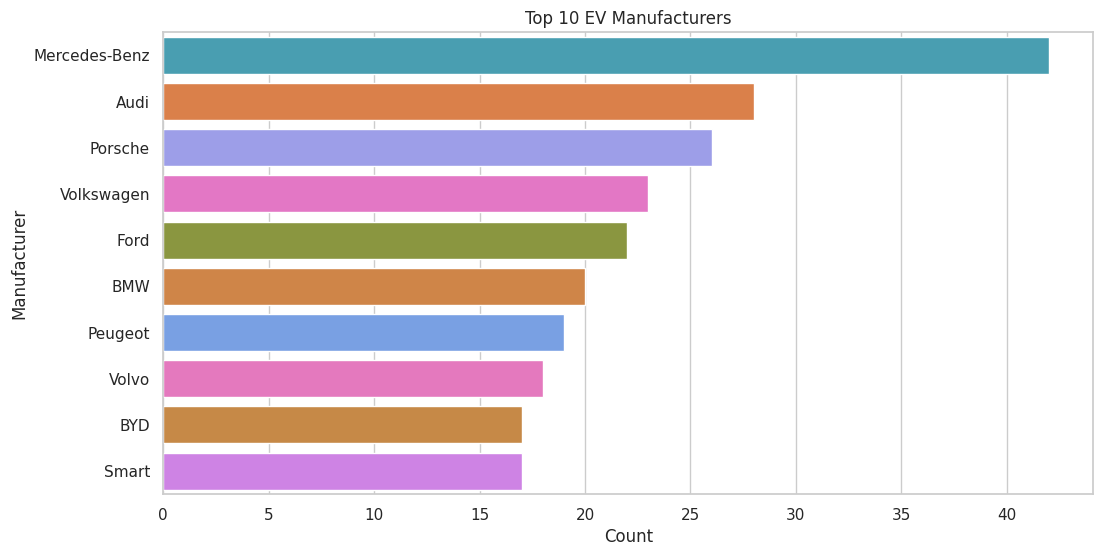

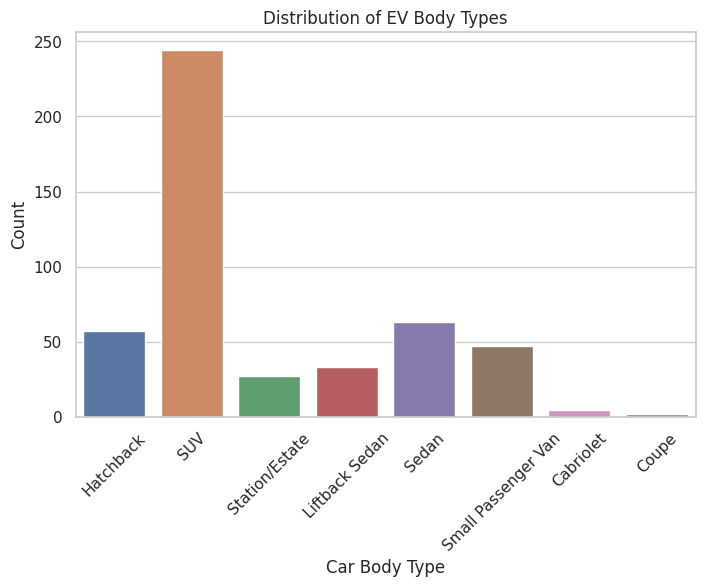

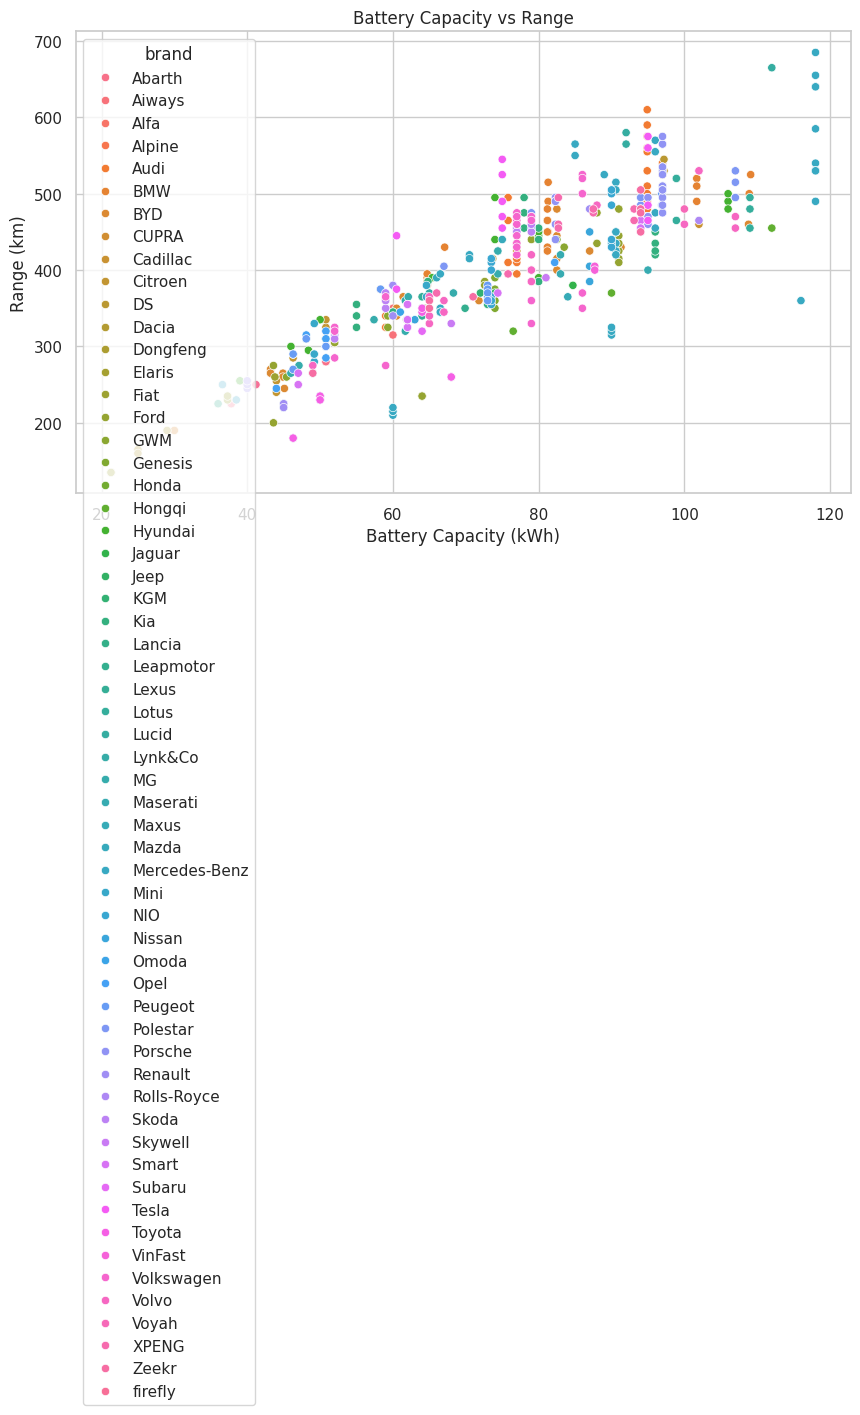

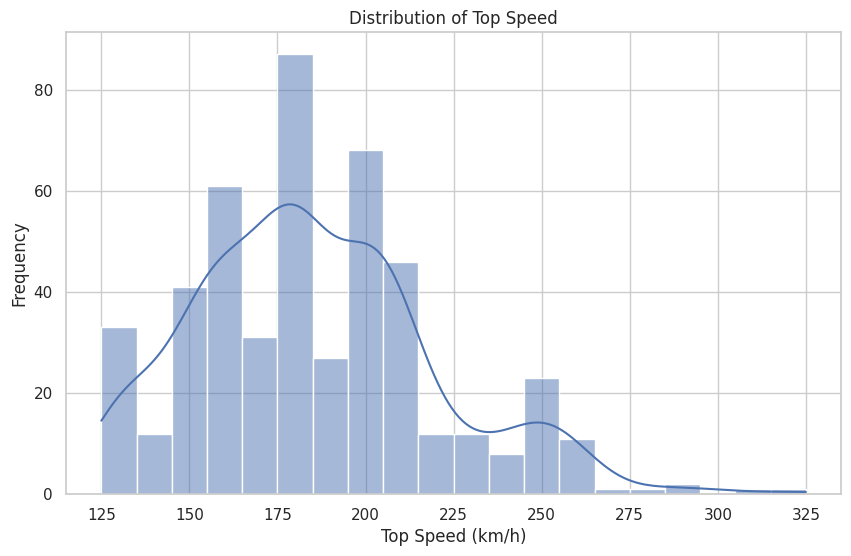

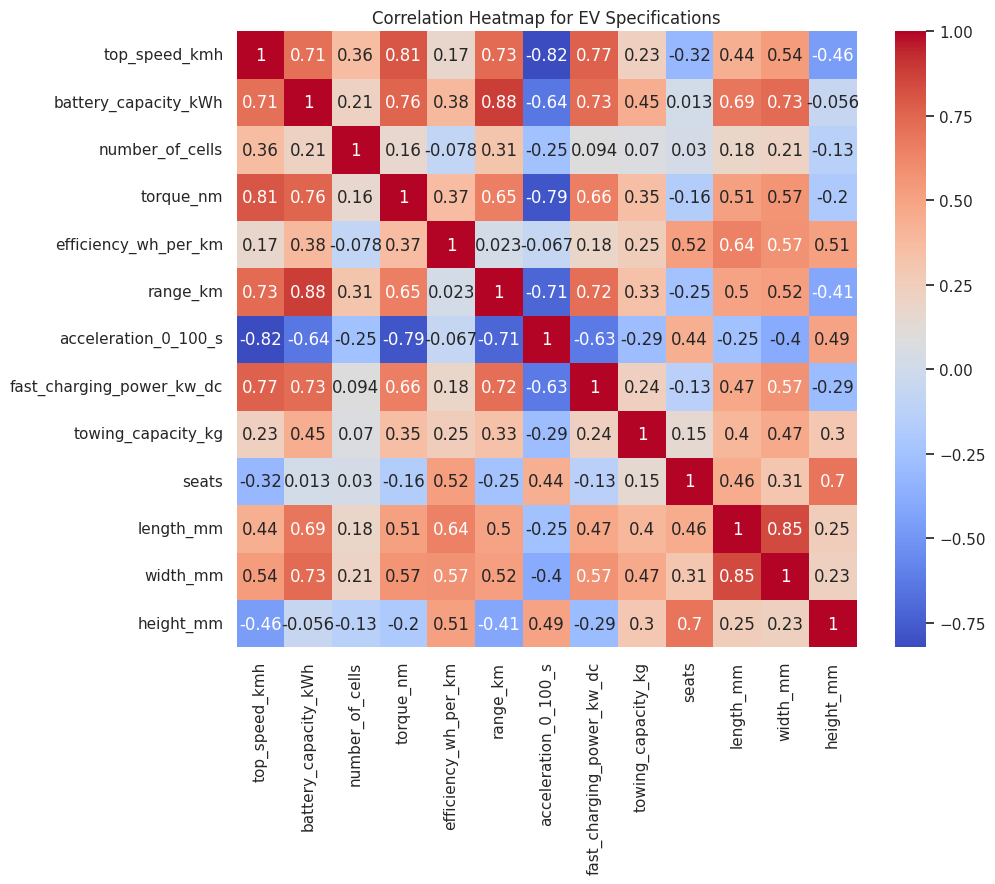


--- Insights Summary ---
Total EV records: 478
EV Manufacturers Count: 59
Most common EV type: SUV
Average Electric Range: 393.1799163179916

Observations:
 SUVs appear highly common among EVs.
 Battery capacity strongly affects range (see heatmap).
 Top 10 manufacturers dominate market share.
 Scatter plot shows larger batteries = more range generally.


In [ ]:
# -------------------------------------------
# EV Market Visualization & Insights Project
# For dataset: electric_vehicles_spec_2025.csv
# -------------------------------------------

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn theme
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("/content/electric_vehicles_spec_2025.csv.csv")

# Preview data
print("Dataset head:")
print(df.head())

# Display basic info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isna().sum())

# -------------------------------
# Visualization 1: Top EV Manufacturers
# -------------------------------

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="brand",
              order=df['brand'].value_counts().head(10).index,
              hue="brand", legend=False)
plt.title("Top 10 EV Manufacturers")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.show()

# -------------------------------
# Visualization 2: EV Body Type Distribution
# -------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="car_body_type", hue="car_body_type", legend=False)
plt.title("Distribution of EV Body Types")
plt.xlabel("Car Body Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# Visualization 3: Battery Capacity vs Range
# -------------------------------

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x="battery_capacity_kWh",
                y="range_km",
                hue="brand")
plt.title("Battery Capacity vs Range")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.show()

# -------------------------------
# Visualization 4: Top Speed Distribution
# -------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["top_speed_kmh"], kde=True)
plt.title("Distribution of Top Speed")
plt.xlabel("Top Speed (km/h)")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# Visualization 5: Correlation Heatmap
# -------------------------------

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for EV Specifications")
plt.show()

# -------------------------------
# Summary Insights
# -------------------------------

print("\n--- Insights Summary ---")

print(f"Total EV records: {len(df)}")
print(f"EV Manufacturers Count: {df['brand'].nunique()}")
print("Most common EV type:", df['car_body_type'].mode()[0])

if "range_km" in df.columns:
    print("Average Electric Range:", numeric_df['range_km'].mean())

print("\nObservations:")
print(" SUVs appear highly common among EVs.")
print(" Battery capacity strongly affects range (see heatmap).")
print(" Top 10 manufacturers dominate market share.")
print(" Scatter plot shows larger batteries = more range generally.")
